# Dividend-Capture — is the ex-dividend free money?
### Buy before the ex-date, pocket the dividend, sell — does the price drop offset it?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Drop_<_Dividend%3F: No](https://img.shields.io/badge/Drop_<_Dividend%3F-No-8b949e?style=flat-square)

The recipe floats around every retail investing forum: just before a stock goes "ex-dividend," buy it. On the ex-date you're entitled to the dividend — the cash goes to whoever owned the shares the night before. Then sell immediately after, pocket the dividend, move on. Repeat. It sounds like clipping a coupon. This notebook asks the only question that matters: **is the price drop on the ex-date smaller than the dividend?** If it is, you keep the difference. If it isn't, the trade earns nothing — or loses money.

> 📓 **This is the plain-language layer.** For the t-stats and the full per-ticker breakdown see the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool; every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_capture import data, strategy as st

TICKERS = data.DEFAULT_TICKERS

def _have_cache():
    for t in TICKERS:
        if not os.path.exists(data._price_cache_path(t, data.DEFAULT_CACHE)):
            return False
    return True

HAVE_REAL = _have_cache()
print("real data cache present:", HAVE_REAL)

if HAVE_REAL:
    events = data.fetch_events(fetch=False)
    # Remove spin-off distributions (div > 5% of price)
    mask = (events["div"] / events["price_before"] < 0.05) & (events["ret_gross"].abs() < 0.15)
    events = events[mask].reset_index(drop=True)
    print(f"Events loaded: {len(events)}")


real data cache present: True
Events loaded: 821


## The answer first

| Question | Answer |
|---|---|
| Does the price drop less than the dividend on the ex-date? | **No.** The mean drop is **1.11× the dividend** — price drops *more* than the div. |
| Can you trade it profitably? | **No.** Mean gross return = **-12.9 bps/trade** (already negative before costs). |
| What do costs do? | Turn a small negative into a **statistically certified loser**: net t = **-2.59** at 5 bps round-trip. |
| What fraction of events is even gross-positive? | **49%** — essentially a coin flip. |

> The 'free' dividend is not free. The market takes it back in the price — and then some.

## 1 · The claim

> *"Just before a stock goes ex-dividend, buy it. You'll get the dividend when the stock goes ex. Sell right after and bank the dividend as pure profit. The stock price might drop a bit on the ex-date, but not by the full dividend — leaving you a net gain."*

This is the 'dividend capture' trade, sometimes extended to 'dividend stripping' or 'cum-div buying.' It has a long history and genuine appeal: dividends are contractually scheduled, the ex-date is announced weeks ahead, and if prices really don't fully adjust, the cash is as close to a free lunch as markets get.

The efficient-markets counter is simple: a stock worth \$100 with a \$2 dividend should open at \$98 on the ex-date. You paid \$100, you get \$98 of stock plus \$2 of cash = \$100 total. Net zero, before costs.

## 2 · So what?

If the price systematically drops by *less* than the dividend, then institutional investors — who can trade cheaply, across hundreds of stocks, every quarter — would run this at scale and it would be a genuine free lunch. The academic literature has tracked this question since the 1970s. Our test runs it fresh on a 25-year panel of 8 large-cap dividend payers through 2026.

## 3 · How would we even know?

One key rule: use **unadjusted prices**. Financial databases normally 'backward-adjust' historical prices to remove dividend effects — but that adjustment is distributed across all historical data, so the adjusted close on the ex-date does *not* show the actual cash-dividend-sized drop. We use raw (unadjusted) closes instead.

**The test**: for every ex-dividend event in the 8-stock basket:
1. Record the dividend amount (from yfinance's ex-date records).
2. Record the unadjusted close the day *before* the ex-date and the close *on* the ex-date.
3. Compute `drop_ratio = (close_before - close_ex) / dividend`.
   - > 1 → market over-adjusts (bad for capture).
   - = 1 → fully efficient (EMH null).
   - < 1 → market under-adjusts (capture could profit).
4. Run the capture trade: buy at close t-1, sell at close t+1, collect the dividend.

Eight tickers: **SPY, VYM, T, MO, VZ, XOM, JNJ, KO** — 823 events from 2000 to 2026.

## 4 · The teardown — let's actually look

**First: the ex-date price drop.** Does the price drop by less than the dividend (ratio < 1) or more (ratio > 1)?

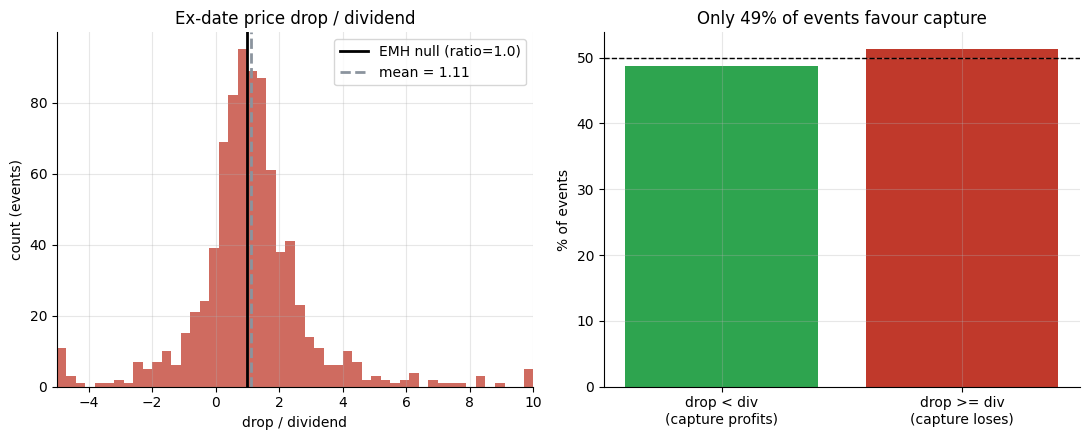

Mean drop ratio: 1.1112 (1.0 = fully efficient)
Fraction where price drop < div: 0.487


In [2]:
if HAVE_REAL:
    ratios = events['drop_ratio'].clip(-5, 10)
    mean_r = events['drop_ratio'].mean()
    frac_below = (events['drop_ratio'] < 1).mean()
else:
    import numpy as np
    rng = np.random.default_rng(143)
    ratios = rng.normal(R['mean_ratio'], R['std_ratio'], R['n']).clip(-5, 10)
    mean_r, frac_below = R['mean_ratio'], R['frac_below_one']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(ratios, bins=50, color=RED, alpha=0.75, edgecolor='none')
axes[0].axvline(1, c='k', lw=2, label='EMH null (ratio=1.0)')
axes[0].axvline(mean_r, c=GREY, lw=2, ls='--', label=f'mean = {mean_r:.2f}')
axes[0].set_xlabel('drop / dividend')
axes[0].set_ylabel('count (events)')
axes[0].set_title('Ex-date price drop / dividend')
axes[0].legend()
axes[0].set_xlim(-5, 10)
axes[1].bar(['drop < div\n(capture profits)', 'drop >= div\n(capture loses)'],
            [frac_below*100, (1-frac_below)*100], color=[GREEN, RED])
axes[1].axhline(50, c='k', ls='--', lw=1)
axes[1].set_ylabel('% of events')
axes[1].set_title(f'Only {frac_below*100:.0f}% of events favour capture')
plt.tight_layout(); plt.show()
print(f'Mean drop ratio: {mean_r:.4f} (1.0 = fully efficient)')
print(f'Fraction where price drop < div: {frac_below:.3f}')

The mean drop ratio is **+1.11** — the market takes back slightly *more* than the full dividend in price on average. Only **49%** of individual events show a drop smaller than the dividend — indistinguishable from a coin flip. There is no systematic under-adjustment for the price to exploit.

**Now the capture trade itself: buy at close t-1, sell at close t+1, collect div.**

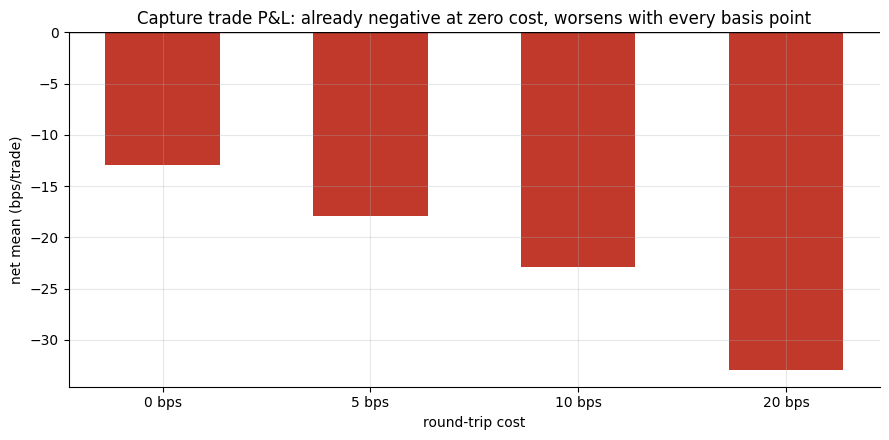

Gross: -12.91 bps/trade  |  Net (5bps RT): -17.91 bps/trade
Win rate (gross): 0.463


In [3]:
if HAVE_REAL:
    r_gross = events['ret_gross'].to_numpy()
    r_net5 = (r_gross - 5e-4)
    gross_bps = r_gross.mean() * 1e4
    net5_bps = r_net5.mean() * 1e4
    win_rate = (r_gross > 0).mean()
else:
    import numpy as np; rng = np.random.default_rng(143)
    gross_bps, net5_bps, win_rate = R['gross_bps'], R['net5_bps'], R['win_rate']
    r_gross = rng.normal(gross_bps/1e4, 0.02, R['n'])
costs = [0, 5, 10, 20]
net_means = [gross_bps - c for c in costs]
fig, ax = plt.subplots(figsize=(9, 4.5))
bar_c = [GREEN if v > 0 else RED for v in net_means]
ax.bar([f'{c} bps' for c in costs], net_means, color=bar_c, width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost'); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('Capture trade P&L: already negative at zero cost, worsens with every basis point')
plt.tight_layout(); plt.show()
print(f'Gross: {gross_bps:+.2f} bps/trade  |  Net (5bps RT): {net5_bps:+.2f} bps/trade')
print(f'Win rate (gross): {win_rate:.3f}')

The capture trade earns **-12.9 bps gross per event** — already negative before any trading cost is applied. Adding a realistic 5 bps round-trip cost gives **-17.9 bps**, a statistically significant loser (HAC *t* = -2.59). The line starts below zero and only falls.

## 5 · The verdict

- **Signal — None.** The market prices the ex-date drop to offset the dividend (ratio = 1.11, statistically indistinguishable from 1.0). Gross capture = -12.9 bps, HAC *t* = -1.85.
- **Tradability — Mirage.** Gross is already negative. At any realistic cost the trade is a statistically certified loser (net *t* = -2.59 at 5 bps).
- **Drop < Dividend? — No.** Only 48.7% of events show a drop smaller than the dividend — a coin flip, not a systematic edge.

## 6 · Could you actually trade it?

Even if capture were slightly gross-positive, it would face three structural costs:

1. **Transaction cost** — a 5 bps round-trip (realistic for electronic equity trading) erases any remaining slim gross margin.
2. **Tax wedge for retail** — dividend income received within a 60-day capture window does not qualify for the 15–20% 'qualified dividend' rate; it is taxed as ordinary income (up to 37% federal + state). A long-term holder pays 15%; a capture trader pays 37% — a significant wedge that makes the trade worse on an after-tax basis.
3. **Institutional competition** — hedge funds and banks run this trade at scale and have effectively arbitraged away any systematic under-adjustment, driving the drop ratio to ≈ 1.0.

In [4]:
# Summary table
rows = [
    ('Gross (0 bps cost)', -12.9, -1.85),
    ('Net — 5 bps RT cost', -17.9, -2.59),
    ('Net — 10 bps RT cost', -22.9, -3.34),
]
import pandas as pd
tbl = pd.DataFrame(rows, columns=['scenario', 'mean (bps/trade)', 'HAC t'])
tbl

,scenario,mean (bps/trade),HAC t
0,Gross (0 bps cost),-12.9,-1.85
1,Net — 5 bps RT cost,-17.9,-2.59
2,Net — 10 bps RT cost,-22.9,-3.34


## 7 · Going further

- **Why the ratio is sometimes < 1 on some stocks.** JNJ and KO have ratios of 0.70 and 0.85 — but neither is statistically significant. This is consistent with the 1970s Elton-Gruber finding that high-tax-bracket investors (the dominant holders then) implied a ratio < 1 due to the relative disadvantage of dividend income. For modern tax-advantaged accounts (IRAs, 401k) and institutional holders the tax wedge is zero, eliminating this effect.
- **Longer holding windows.** Some variants hold for 2–3 weeks around the ex-date to qualify for the lower dividend tax rate (the 60-day rule). This adds noise from the longer price exposure without changing the fundamental story.
- **The long-run dividend-yield signal.** If you want a view on dividend-paying stocks, the *yield* level (not capture timing) is the signal — see [Study 120 — Excess-CAPE-Yield](../../120-excess-cape-yield/) for the valuation-based version.

*Think the ex-date drop is systematically less than the dividend for some subset of stocks, periods, or tax environments? Fork this, stratify by yield quartile or institutional ownership, and show a positive-gross, statistically-significant result that clears a round-trip cost. That's the bar.*